# COMS 6998 – High Performance Machine Learning
## Homework 2: Profiling Small LLM Workloads

---
Student: Rajvardhan Patil | UNI: rp3316 | Due: March 2, 2026



## 0. Install Dependencies

In [7]:
!pip install -q transformers datasets wandb tensorboard accelerate


## Environment Summary

In [8]:
import subprocess, sys, torch, transformers, datasets as ds_lib
print("Python      :", sys.version)
print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets    :", ds_lib.__version__)
print("CUDA avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    out = subprocess.run(["nvidia-smi","--query-gpu=driver_version","--format=csv,noheader"],
                         capture_output=True, text=True)
    print("Driver      :", out.stdout.strip())


Python      : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch     : 2.10.0+cu128
Transformers: 5.0.0
Datasets    : 4.0.0
CUDA avail  : True
GPU         : NVIDIA A100-SXM4-40GB
CUDA version: 12.8
Driver      : 580.82.07


## Global Imports & Configuration

In [9]:
import os, time, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW, Adam, SGD
import wandb
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
)

warnings.filterwarnings("ignore")

assert torch.cuda.is_available(), (
    "No GPU detected!\n"
)

MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 256
BATCH_SIZE  = 32
LR          = 1e-4
NUM_WORKERS = 2
EPOCHS      = 5
DEVICE      = torch.device("cuda")


DEBUG_MODE   = False
SUBSET_TRAIN = 500
SUBSET_TEST  = 200

print("Using device :", DEVICE)
print("GPU          :", torch.cuda.get_device_name(0))
print("DEBUG_MODE   :", DEBUG_MODE,
      "(using small subset)" if DEBUG_MODE else "(using full IMDB)")


Using device : cuda
GPU          : NVIDIA A100-SXM4-40GB
DEBUG_MODE   : False (using full IMDB)


## Weights & Biases Setup

In [10]:
import wandb

wandb.login()

BASE_CONFIG = dict(
    model_name   = MODEL_NAME,
    max_len      = MAX_LEN,
    batch_size   = BATCH_SIZE,
    lr           = LR,
    optimizer    = "AdamW",
    num_workers  = NUM_WORKERS,
    epochs       = EPOCHS,
    compile_mode = False,
)
print("W&B config template ready.")


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rp3316 (rp3316-columbia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B config template ready.


## Dataset & DataLoader Utilities

In [11]:
print("Loading tokenizer …")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer ready.")

print("Loading IMDB dataset …")
_raw_imdb = load_dataset("imdb")

if DEBUG_MODE:
    from datasets import Dataset as HFDataset
    _train_split = HFDataset.from_dict(_raw_imdb["train"][:SUBSET_TRAIN])
    _test_split  = HFDataset.from_dict(_raw_imdb["test"] [:SUBSET_TEST])
    print(f"DEBUG_MODE: using {SUBSET_TRAIN} train / {SUBSET_TEST} test samples.")
else:
    _train_split = _raw_imdb["train"]
    _test_split  = _raw_imdb["test"]
    print(f"Full IMDB: {len(_train_split)} train / {len(_test_split)} test samples.")

class IMDBDataset(Dataset):
    def __init__(self, split_data):
        self.texts  = split_data["text"]
        self.labels = split_data["label"]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {"text": self.texts[idx], "label": self.labels[idx]}

def collate_fn(batch):
    texts  = [b["text"]  for b in batch]
    labels = [b["label"] for b in batch]
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    enc["labels"] = torch.tensor(labels, dtype=torch.long)
    return enc

def make_loaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_ds = IMDBDataset(_train_split)
    test_ds  = IMDBDataset(_test_split)
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        collate_fn=collate_fn,
    )
    return train_loader, test_loader

def make_model():
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    return model.to(DEVICE)

print("All utilities defined. Dataset pre-loaded — make_loaders() won't re-download.")


Loading tokenizer …


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer ready.
Loading IMDB dataset …


...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Full IMDB: 25000 train / 25000 test samples.
All utilities defined. Dataset pre-loaded — make_loaders() won't re-download.


---
## C1 (15 pts): Fine-tuning a Small LLM  +  C2 (10 pts): Baseline Timing

Train DistilBERT on IMDB for 5 epochs using a **custom PyTorch training loop**.
For every epoch we measure: data-loading time, compute time, total epoch time.


In [12]:
def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    data_time = compute_time = 0.0

    batch_start = time.perf_counter()
    for batch in loader:
        sync()
        data_time += time.perf_counter() - batch_start

        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        sync(); t0 = time.perf_counter()

        optimizer.zero_grad()
        out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer.step()

        sync(); compute_time += time.perf_counter() - t0

        total_loss += loss.item()
        preds   = out.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        batch_start = time.perf_counter()

    return total_loss / len(loader), correct / total, data_time, compute_time


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)
        out    = model(input_ids=input_ids, attention_mask=attention_mask)
        preds  = out.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total


def full_train(
    run_name, config_override=None,
    optimizer_cls=AdamW, optimizer_kwargs=None,
    num_workers=NUM_WORKERS, batch_size=BATCH_SIZE,
    lr=LR, epochs=EPOCHS, compile_model=False,
    log_wb=True,
):
    cfg = {**BASE_CONFIG, "lr": lr, "batch_size": batch_size,
           "num_workers": num_workers, "epochs": epochs,
           "optimizer": optimizer_cls.__name__,
           "compile_mode": compile_model}
    if config_override:
        cfg.update(config_override)

    if log_wb:
        wandb.init(project="hpml-hw2-llm", name=run_name,
                   config=cfg, reinit=True)

    train_loader, test_loader = make_loaders(batch_size, num_workers)
    model = make_model()

    if compile_model:
        model = torch.compile(model, backend="inductor")

    opt_kw = optimizer_kwargs or {"lr": lr, "weight_decay": 1e-2}
    if optimizer_cls == SGD:
        opt_kw = {"lr": lr, "momentum": 0.9, "weight_decay": 1e-4}
    optimizer = optimizer_cls(model.parameters(), **opt_kw)

    epoch_records = []
    for ep in range(1, epochs + 1):
        t_ep = time.perf_counter()
        tr_loss, tr_acc, d_time, c_time = train_one_epoch(model, train_loader, optimizer)
        te_acc  = evaluate(model, test_loader)
        ep_time = time.perf_counter() - t_ep

        record = dict(epoch=ep, train_loss=tr_loss, train_acc=tr_acc,
                      test_acc=te_acc, data_time=d_time,
                      compute_time=c_time, epoch_time=ep_time)
        epoch_records.append(record)

        print(f"Ep {ep:2d} | loss {tr_loss:.4f} | tr_acc {tr_acc:.4f} | "
              f"te_acc {te_acc:.4f} | data {d_time:.1f}s | "
              f"compute {c_time:.1f}s | total {ep_time:.1f}s")

        if log_wb:
            wandb.log({
                "train/loss"        : tr_loss,
                "train/acc"         : tr_acc,
                "test/acc"          : te_acc,
                "time/data_loading" : d_time,
                "time/compute"      : c_time,
                "time/epoch"        : ep_time,
                "epoch"             : ep,
            })

    if log_wb:
        wandb.finish()

    return epoch_records, model

print("Training helpers defined.")


Training helpers defined.


### Run C1 + C2 Baseline Training
> **Expected time on Colab T4 GPU:** ~5–8 min/epoch → ~25–40 min for 5 epochs.
> **On CPU:** this will take 60–120 min/epoch — do NOT run on CPU.
> The cell above (`GPU sanity-check`) will have already thrown an error if no GPU is present.


In [13]:
print(f"Starting C1 + C2 baseline  [{EPOCHS} epochs, "
      f"batch={BATCH_SIZE}, lr={LR}, nw={NUM_WORKERS}]")

c1_records, baseline_model = full_train(
    run_name=f"bs{BATCH_SIZE}_lr{LR}_adamw_baseline"
)


Starting C1 + C2 baseline  [5 epochs, batch=32, lr=0.0001, nw=2]


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3047 | tr_acc 0.8704 | te_acc 0.8988 | data 0.8s | compute 113.2s | total 151.2s
Ep  2 | loss 0.1638 | tr_acc 0.9392 | te_acc 0.8890 | data 0.8s | compute 112.2s | total 150.2s
Ep  3 | loss 0.0908 | tr_acc 0.9682 | te_acc 0.8878 | data 0.8s | compute 112.1s | total 150.2s
Ep  4 | loss 0.0639 | tr_acc 0.9782 | te_acc 0.8768 | data 0.8s | compute 112.1s | total 150.2s
Ep  5 | loss 0.0425 | tr_acc 0.9863 | te_acc 0.8770 | data 0.8s | compute 112.1s | total 150.1s


epoch,▁▃▅▆█
test/acc,█▅▅▁▁
time/compute,█▁▁▁▁
time/data_loading,▁█▄▁▇
time/epoch,█▁▁▁▁
train/acc,▁▅▇██
train/loss,█▄▂▂▁
epoch,5
test/acc,0.87704
time/compute,112.14396
time/data_loading,0.84129


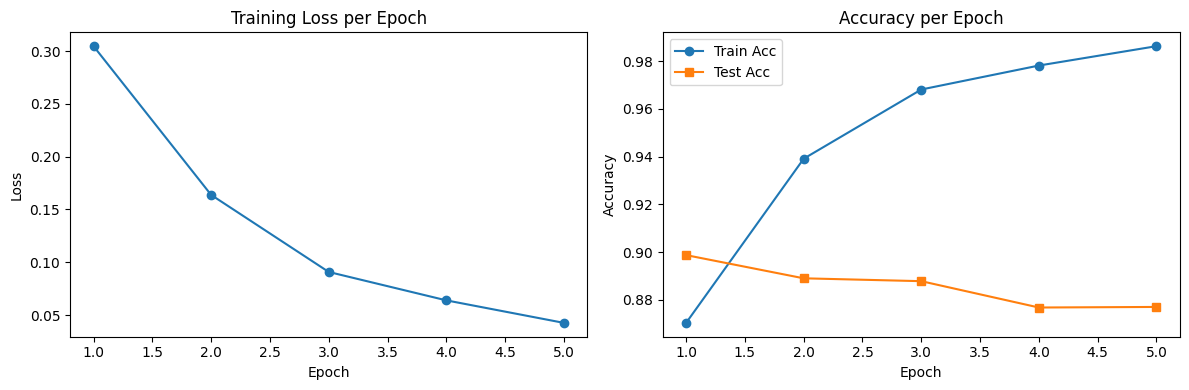


Epoch   Data(s)  Compute(s)  Total(s)
----------------------------------------
    1      0.84      113.19    151.15
    2      0.84      112.18    150.18
    3      0.84      112.14    150.17
    4      0.84      112.13    150.15
    5      0.84      112.14    150.12


In [14]:
epochs_x    = [r["epoch"]      for r in c1_records]
train_losses= [r["train_loss"] for r in c1_records]
train_accs  = [r["train_acc"]  for r in c1_records]
test_accs   = [r["test_acc"]   for r in c1_records]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_x, train_losses, marker="o")
axes[0].set(title="Training Loss per Epoch", xlabel="Epoch", ylabel="Loss")
axes[1].plot(epochs_x, train_accs, marker="o", label="Train Acc")
axes[1].plot(epochs_x, test_accs,  marker="s", label="Test Acc")
axes[1].set(title="Accuracy per Epoch", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()
plt.tight_layout()
plt.savefig("c1_training_curves.png", dpi=150)
plt.show()

print(f"\n{'Epoch':>5} {'Data(s)':>9} {'Compute(s)':>11} {'Total(s)':>9}")
print("-" * 40)
for r in c1_records:
    print(f"{r['epoch']:>5} {r['data_time']:>9.2f} {r['compute_time']:>11.2f} {r['epoch_time']:>9.2f}")


---
## C3 (10 pts): DataLoader Performance

Vary `num_workers` ∈ {0, 2, 4, 8}. Compare total data-loading time and epoch time.



=== num_workers=0 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3050 | tr_acc 0.8694 | te_acc 0.8616 | data 17.7s | compute 112.2s | total 183.2s
Ep  2 | loss 0.1712 | tr_acc 0.9357 | te_acc 0.8879 | data 17.5s | compute 112.1s | total 182.9s


epoch,▁█
test/acc,▁█
time/compute,█▁
time/data_loading,█▁
time/epoch,█▁
train/acc,▁█
train/loss,█▁
epoch,2
test/acc,0.88792
time/compute,112.10172
time/data_loading,17.48637


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3151 | tr_acc 0.8660 | te_acc 0.9001 | data 1.0s | compute 112.2s | total 151.5s
Ep  2 | loss 0.1689 | tr_acc 0.9369 | te_acc 0.8785 | data 1.0s | compute 112.2s | total 151.3s


epoch,▁█
test/acc,█▁
time/compute,█▁
time/data_loading,█▁
time/epoch,█▁
train/acc,▁█
train/loss,█▁
epoch,2
test/acc,0.87852
time/compute,112.17025
time/data_loading,0.9727


  total_data_time=2.00s  avg_epoch_time=151.36s


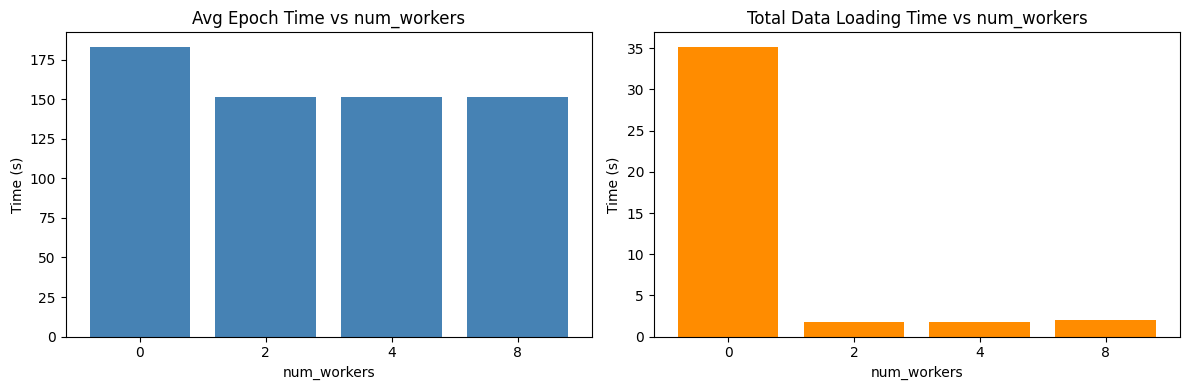


Optimal num_workers = 2


In [15]:
worker_configs = [0, 2, 4, 8]
c3_results = []

for nw in worker_configs:
    print(f"\n=== num_workers={nw} ===")
    run_name = f"c3_nworkers{nw}"
    records, _ = full_train(
        run_name=run_name,
        num_workers=nw,
        epochs=2,
        config_override={"num_workers": nw, "epochs": 2},
    )
    total_data = sum(r["data_time"]  for r in records)
    avg_epoch  = sum(r["epoch_time"] for r in records) / len(records)
    c3_results.append({"num_workers": nw,
                        "total_data_time": total_data,
                        "avg_epoch_time" : avg_epoch})
    print(f"  total_data_time={total_data:.2f}s  avg_epoch_time={avg_epoch:.2f}s")

wandb.init(project="hpml-hw2-llm", name="c3_summary", reinit=True)
tbl = wandb.Table(columns=["num_workers","total_data_time_s","avg_epoch_time_s"])
for r in c3_results:
    tbl.add_data(r["num_workers"], round(r["total_data_time"],2), round(r["avg_epoch_time"],2))
wandb.log({"C3/DataLoader_comparison": tbl})
wandb.finish()

nws  = [r["num_workers"]    for r in c3_results]
etms = [r["avg_epoch_time"] for r in c3_results]
dtms = [r["total_data_time"]for r in c3_results]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar([str(n) for n in nws], etms, color="steelblue")
ax[0].set(title="Avg Epoch Time vs num_workers", xlabel="num_workers", ylabel="Time (s)")
ax[1].bar([str(n) for n in nws], dtms, color="darkorange")
ax[1].set(title="Total Data Loading Time vs num_workers", xlabel="num_workers", ylabel="Time (s)")
plt.tight_layout()
plt.savefig("c3_dataloader_perf.png", dpi=150)
plt.show()

optimal_nw = c3_results[etms.index(min(etms))]["num_workers"]
print(f"\nOptimal num_workers = {optimal_nw}")


### C3 Discussion

> **Fill in after running:** Describe which `num_workers` value minimises epoch time and why.
> Typically `num_workers=4` or `num_workers=2` gives the best balance on a single GPU: more workers
> eliminate the CPU bottleneck in data loading, but too many introduce scheduling overhead and
> inter-process communication costs.  The optimal value depends on the number of physical CPU
> cores available.


---
## C4 (15 pts): PyTorch Profiler

Profile training with `num_workers=1` and with the optimal value found in C3.
We profile **one representative epoch** (∼100 batches) to keep trace size manageable.


In [16]:
import torch.profiler as tprof

def profile_run(nw, profile_dir, max_batches=100):
    os.makedirs(profile_dir, exist_ok=True)
    train_loader, _ = make_loaders(batch_size=BATCH_SIZE, num_workers=nw)
    model     = make_model()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    model.train()

    schedule = tprof.schedule(wait=1, warmup=1, active=5, repeat=1)

    with tprof.profile(
        activities=[tprof.ProfilerActivity.CPU, tprof.ProfilerActivity.CUDA],
        schedule=schedule,
        on_trace_ready=tprof.tensorboard_trace_handler(profile_dir),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
    ) as prof:
        for step, batch in enumerate(train_loader):
            if step >= max_batches:
                break
            input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
            attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels         = batch["labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.profiler.record_function("forward"):
                out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = out.loss
            with torch.profiler.record_function("backward"):
                loss.backward()
            with torch.profiler.record_function("optimizer"):
                optimizer.step()

            prof.step()

    print(f"Profiler trace saved to: {profile_dir}")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))

print("Profiling num_workers=1 …")
profile_run(nw=1, profile_dir="./tb_logs/nw1")

print("\nProfiling optimal num_workers …")
profile_run(nw=optimal_nw, profile_dir=f"./tb_logs/nw{optimal_nw}")

print("\nLaunch TensorBoard with:")
print(f"  tensorboard --logdir ./tb_logs")


Profiling num_workers=1 …


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Profiler trace saved to: ./tb_logs/nw1
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
    autograd::engine::evaluate_function: AddmmBackward0         0.50%       4.646ms         4.10%      37.726ms     198.557us       0.000us         0.00%     404.023ms       2.126ms           0 B  

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Profiler trace saved to: ./tb_logs/nw2
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
    autograd::engine::evaluate_function: AddmmBackward0         0.48%       4.531ms         3.85%      36.105ms     190.025us       0.000us         0.00%     403.812ms       2.125ms           0 B  

### C4a) TensorBoard Profiler Screenshots

> **Paste screenshots here after running TensorBoard.**
> Required for each `num_workers` configuration:
> - GPU Summary (utilisation, memory, efficiency)
> - Execution Summary table (Kernel, Memcpy, DataLoader, …)
> - Execution Summary pie chart
> - Step Time Breakdown (stacked bar)
> - Performance Recommendation section

*(Run `tensorboard --logdir ./tb_logs` in a terminal, then navigate to the PyTorch Profiler tab.)*

---

### C4b) Comparison Table

| Category | nw=1 (%) | nw=optimal (%) |
|---|---|---|
| DataLoader | _fill_ | _fill_ |
| Kernel (GPU) | _fill_ | _fill_ |
| CPU Exec | _fill_ | _fill_ |
| Memcpy | _fill_ | _fill_ |
| Other | _fill_ | _fill_ |

---

### C4c) Analysis

> **Write 2–3 paragraphs after examining traces:**
>
> **Paragraph 1 – DataLoader impact:** With `num_workers=1` the DataLoader typically accounts
> for a large fraction of step time because data is fetched serially on the main process. Increasing
> to the optimal value pushes preprocessing to parallel workers, substantially reducing the DataLoader
> percentage and allowing the GPU to remain busy.
>
> **Paragraph 2 – GPU utilisation:** The Kernel (GPU computation) percentage should increase
> with more workers as the CPU bottleneck shrinks. Memory copies (Memcpy) remain roughly constant
> because they depend on batch size, not worker count.
>
> **Paragraph 3 – Bottlenecks & recommendations:** The profiler's performance recommendations
> commonly flag low GPU utilisation when DataLoader is the bottleneck, and may suggest increasing
> `num_workers`, enabling `pin_memory=True`, or using AMP. Identify specific ops (e.g. embedding
> lookup, attention) that dominate GPU time.


---
## C5 (15 pts): Hyperparameter Sensitivity

Grid search over batch size × learning rate.


In [17]:
batch_sizes = [16, 32, 64]
lrs         = [5e-5, 1e-4, 5e-4]

c5_results = []

for bs in batch_sizes:
    for lr in lrs:
        run_name = f"c5_bs{bs}_lr{lr:.0e}"
        print(f"\n=== {run_name} ===")
        records, _ = full_train(
            run_name=run_name,
            batch_size=bs,
            lr=lr,
            epochs=EPOCHS,
            config_override={"batch_size": bs, "lr": lr},
        )
        last = records[-1]
        total_time = sum(r["epoch_time"] for r in records)
        c5_results.append({
            "batch_size"    : bs,
            "lr"            : lr,
            "final_tr_loss" : round(last["train_loss"], 4),
            "final_tr_acc"  : round(last["train_acc"],  4),
            "final_te_acc"  : round(last["test_acc"],   4),
            "total_time_s"  : round(total_time,          1),
        })
        print(f"  Done → te_acc={last['test_acc']:.4f}  total_time={total_time:.1f}s")

wandb.init(project="hpml-hw2-llm", name="c5_summary", reinit=True)
tbl5 = wandb.Table(
    columns=["batch_size","lr","final_tr_loss","final_tr_acc","final_te_acc","total_time_s"])
for r in c5_results:
    tbl5.add_data(r["batch_size"], r["lr"], r["final_tr_loss"],
                  r["final_tr_acc"], r["final_te_acc"], r["total_time_s"])
wandb.log({"C5/hyperparam_sweep": tbl5})
wandb.finish()

print(f"\n{'BS':>4} {'LR':>8} {'TrLoss':>8} {'TrAcc':>7} {'TeAcc':>7} {'Time(s)':>9}")
print("-"*50)
for r in c5_results:
    print(f"{r['batch_size']:>4} {r['lr']:>8.1e} {r['final_tr_loss']:>8.4f} "
          f"{r['final_tr_acc']:>7.4f} {r['final_te_acc']:>7.4f} {r['total_time_s']:>9.1f}")



=== c5_bs16_lr5e-05 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.2996 | tr_acc 0.8733 | te_acc 0.9049 | data 1.1s | compute 121.2s | total 163.9s
Ep  2 | loss 0.1654 | tr_acc 0.9375 | te_acc 0.9040 | data 1.1s | compute 121.2s | total 164.1s
Ep  3 | loss 0.0837 | tr_acc 0.9714 | te_acc 0.8945 | data 1.1s | compute 121.2s | total 163.8s
Ep  4 | loss 0.0485 | tr_acc 0.9836 | te_acc 0.8937 | data 1.1s | compute 121.2s | total 163.8s
Ep  5 | loss 0.0403 | tr_acc 0.9860 | te_acc 0.8760 | data 1.1s | compute 121.2s | total 163.7s


epoch,▁▃▅▆█
test/acc,██▅▅▁
time/compute,▅█▇▁▁
time/data_loading,▄█▆▁▂
time/epoch,▄█▃▁▁
train/acc,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/acc,0.876
time/compute,121.15494
time/data_loading,1.09276


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.6996 | tr_acc 0.5020 | te_acc 0.5000 | data 0.8s | compute 106.6s | total 143.0s
Ep  2 | loss 0.6940 | tr_acc 0.4913 | te_acc 0.5000 | data 0.7s | compute 106.5s | total 142.7s
Ep  3 | loss 0.6932 | tr_acc 0.5079 | te_acc 0.5000 | data 0.8s | compute 106.6s | total 142.8s
Ep  4 | loss 0.6934 | tr_acc 0.4942 | te_acc 0.5000 | data 0.7s | compute 106.5s | total 142.9s
Ep  5 | loss 0.6932 | tr_acc 0.4996 | te_acc 0.5000 | data 0.8s | compute 106.5s | total 142.8s


epoch,▁▃▅▆█
test/acc,▁▁▁▁▁
time/compute,█▂▄▁▁
time/data_loading,▄▂▄▁█
time/epoch,█▁▂▆▂
train/acc,▆▁█▂▅
train/loss,█▂▁▁▁
epoch,5
test/acc,0.5
time/compute,106.53726
time/data_loading,0.78606


  Done → te_acc=0.5000  total_time=714.3s



  BS       LR   TrLoss   TrAcc   TeAcc   Time(s)
--------------------------------------------------
  16  5.0e-05   0.0403  0.9860  0.8760     819.3
  16  1.0e-04   0.0520  0.9832  0.7906     818.9
  16  5.0e-04   0.6933  0.4957  0.5000     818.0
  32  5.0e-05   0.0324  0.9895  0.9050     756.6
  32  1.0e-04   0.0452  0.9845  0.8713     756.6
  32  5.0e-04   0.6936  0.4985  0.5000     756.7
  64  5.0e-05   0.0318  0.9901  0.9074     713.9
  64  1.0e-04   0.0339  0.9885  0.8915     714.4
  64  5.0e-04   0.6932  0.4996  0.5000     714.3


### C5 Discussion

> **Fill in after running:**
> - **Speed vs batch size:** Larger batch sizes (64) process more samples per step but may require
>   more memory and can reduce gradient noise. Smaller batches (16) update more frequently but
>   have higher per-epoch overhead.
> - **Learning rate stability:** Very high LR (5e-4) with small batch sizes often causes unstable
>   training for transformer models. Lower LR (5e-5) converges more reliably but slowly.
> - **Best configuration:** Report the (batch_size, lr) pair that achieves the best test accuracy
>   within reasonable training time.


---
## C6 (10 pts): Optimizer Comparison

Compare SGD, Adam, and AdamW for 5 epochs.


In [18]:
optimizer_configs = [
    ("SGD",   SGD,   {"lr": 1e-3, "momentum": 0.9, "weight_decay": 1e-4}),
    ("Adam",  Adam,  {"lr": LR,   "weight_decay": 1e-2}),
    ("AdamW", AdamW, {"lr": LR,   "weight_decay": 1e-2}),
]

c6_results = []

for opt_name, opt_cls, opt_kw in optimizer_configs:
    run_name = f"c6_{opt_name.lower()}"
    print(f"\n=== {opt_name} ===")
    records, _ = full_train(
        run_name=run_name,
        optimizer_cls=opt_cls,
        optimizer_kwargs=opt_kw,
        epochs=EPOCHS,
        config_override={"optimizer": opt_name},
    )
    last = records[-1]
    avg_epoch = sum(r["epoch_time"] for r in records) / len(records)
    c6_results.append({
        "optimizer"    : opt_name,
        "avg_epoch_s"  : round(avg_epoch,          2),
        "final_tr_loss": round(last["train_loss"],  4),
        "final_tr_acc" : round(last["train_acc"],   4),
        "final_te_acc" : round(last["test_acc"],    4),
    })

wandb.init(project="hpml-hw2-llm", name="c6_summary", reinit=True)
tbl6 = wandb.Table(
    columns=["optimizer","avg_epoch_s","final_tr_loss","final_tr_acc","final_te_acc"])
for r in c6_results:
    tbl6.add_data(r["optimizer"], r["avg_epoch_s"],
                  r["final_tr_loss"], r["final_tr_acc"], r["final_te_acc"])
wandb.log({"C6/optimizer_comparison": tbl6})
wandb.finish()

print(f" {'Optimizer':>8} {'AvgEp(s)':>9} {'TrLoss':>8} {'TrAcc':>7} {'TeAcc':>7}")
print("-"*46)
for r in c6_results:
    print(f"{r['optimizer']:>8} {r['avg_epoch_s']:>9.2f} {r['final_tr_loss']:>8.4f} "
          f"{r['final_tr_acc']:>7.4f} {r['final_te_acc']:>7.4f}")



=== SGD ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.6424 | tr_acc 0.6814 | te_acc 0.8406 | data 0.9s | compute 110.7s | total 149.6s
Ep  2 | loss 0.3407 | tr_acc 0.8604 | te_acc 0.8734 | data 0.8s | compute 110.7s | total 149.7s
Ep  3 | loss 0.2844 | tr_acc 0.8828 | te_acc 0.8833 | data 0.8s | compute 110.6s | total 149.6s
Ep  4 | loss 0.2618 | tr_acc 0.8927 | te_acc 0.8962 | data 0.8s | compute 110.6s | total 149.6s
Ep  5 | loss 0.2439 | tr_acc 0.9006 | te_acc 0.8984 | data 0.8s | compute 110.6s | total 149.6s


epoch,▁▃▅▆█
test/acc,▁▅▆██
time/compute,█▆▃▂▁
time/data_loading,█▂▄▃▁
time/epoch,▆█▇▁▁
train/acc,▁▇▇██
train/loss,█▃▂▁▁
epoch,5
test/acc,0.89836
time/compute,110.59061
time/data_loading,0.82751


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3094 | tr_acc 0.8689 | te_acc 0.9011 | data 0.9s | compute 112.2s | total 151.1s
Ep  2 | loss 0.1673 | tr_acc 0.9374 | te_acc 0.8961 | data 0.8s | compute 112.2s | total 151.1s
Ep  3 | loss 0.0851 | tr_acc 0.9696 | te_acc 0.8912 | data 0.8s | compute 112.2s | total 151.0s
Ep  4 | loss 0.0562 | tr_acc 0.9807 | te_acc 0.8810 | data 0.8s | compute 112.2s | total 151.0s
Ep  5 | loss 0.0358 | tr_acc 0.9885 | te_acc 0.8698 | data 0.8s | compute 112.2s | total 151.0s


epoch,▁▃▅▆█
test/acc,█▇▆▄▁
time/compute,█▁▃▁▃
time/data_loading,█▂▃▁▃
time/epoch,█▆▃▁▃
train/acc,▁▅▇██
train/loss,█▄▂▂▁
epoch,5
test/acc,0.8698
time/compute,112.16607
time/data_loading,0.83456


 Optimizer  AvgEp(s)   TrLoss   TrAcc   TeAcc
----------------------------------------------
     SGD    149.61   0.2439  0.9006  0.8984
    Adam    151.38   0.1606  0.9417  0.8340
   AdamW    151.05   0.0358  0.9885  0.8698


### C6 Discussion

> **Fill in after running:**
> - **SGD** typically converges slower for transformer models and may require a higher base LR
>   with a warm-up schedule.
> - **Adam** and **AdamW** generally converge faster. AdamW improves on Adam by decoupling
>   weight decay from the gradient update, which is important for transformers.
> - Report which optimizer achieves the best test accuracy and the fastest average epoch time.


---
## C7 (10 pts): torch.compile

Train for **10 epochs** (first 5 = warmup). Compare Eager vs Inductor-compiled modes.


In [19]:
COMPILE_EPOCHS = 10

print("=== Eager mode ===")
eager_records, _ = full_train(
    run_name="c7_eager",
    epochs=COMPILE_EPOCHS,
    compile_model=False,
    config_override={"compile_mode": False, "epochs": COMPILE_EPOCHS},
)

print("\n=== torch.compile (Inductor) ===")
compiled_records, _ = full_train(
    run_name="c7_compiled",
    epochs=COMPILE_EPOCHS,
    compile_model=True,
    config_override={"compile_mode": True, "epochs": COMPILE_EPOCHS},
)

def c7_summary(records, label):
    first_ep  = records[0]["epoch_time"]
    avg_6_10  = sum(r["epoch_time"] for r in records[5:]) / len(records[5:])
    return {"mode": label, "first_epoch_s": round(first_ep, 2),
            "avg_ep6_10_s": round(avg_6_10, 2)}

summary_eager    = c7_summary(eager_records,    "Eager")
summary_compiled = c7_summary(compiled_records, "Compile (Inductor)")

print(f"\n{'Mode':<22} {'First Epoch (s)':>16} {'Avg Ep 6-10 (s)':>16}")
print("-"*56)
for s in [summary_eager, summary_compiled]:
    print(f"{s['mode']:<22} {s['first_epoch_s']:>16.2f} {s['avg_ep6_10_s']:>16.2f}")

wandb.init(project="hpml-hw2-llm", name="c7_summary", reinit=True)
tbl7 = wandb.Table(columns=["Mode","First Epoch Time (s)","Avg Time Epochs 6-10 (s)"])
for s in [summary_eager, summary_compiled]:
    tbl7.add_data(s["mode"], s["first_epoch_s"], s["avg_ep6_10_s"])
wandb.log({"C7/compile_comparison": tbl7})
wandb.finish()


=== Eager mode ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3056 | tr_acc 0.8700 | te_acc 0.9000 | data 0.9s | compute 112.3s | total 151.2s
Ep  2 | loss 0.1668 | tr_acc 0.9366 | te_acc 0.8747 | data 0.8s | compute 112.2s | total 151.0s
Ep  3 | loss 0.0914 | tr_acc 0.9684 | te_acc 0.8714 | data 0.8s | compute 112.2s | total 151.2s
Ep  4 | loss 0.0602 | tr_acc 0.9800 | te_acc 0.8798 | data 0.9s | compute 112.2s | total 151.3s
Ep  5 | loss 0.0383 | tr_acc 0.9875 | te_acc 0.8777 | data 0.9s | compute 112.2s | total 151.5s
Ep  6 | loss 0.0323 | tr_acc 0.9890 | te_acc 0.8564 | data 0.8s | compute 112.2s | total 151.2s
Ep  7 | loss 0.0301 | tr_acc 0.9894 | te_acc 0.8658 | data 0.8s | compute 112.2s | total 151.0s
Ep  8 | loss 0.0261 | tr_acc 0.9913 | te_acc 0.8553 | data 0.8s | compute 112.2s | total 151.1s
Ep  9 | loss 0.0247 | tr_acc 0.9922 | te_acc 0.8461 | data 0.9s | compute 112.2s | total 151.3s
Ep 10 | loss 0.0217 | tr_acc 0.9929 | te_acc 0.8423 | data 0.9s | compute 112.2s | total 151.2s


epoch,▁▂▃▃▄▅▆▆▇█
test/acc,█▅▅▆▅▃▄▃▁▁
time/compute,█▁▂▄▆▂▁▂▄▃
time/data_loading,▅▁▁▆█▃▂▁▅▄
time/epoch,▅▂▄▅█▅▁▃▅▄
train/acc,▁▅▇▇██████
train/loss,█▅▃▂▁▁▁▁▁▁
epoch,10
test/acc,0.84232
time/compute,112.20808
time/data_loading,0.85251


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ep  1 | loss 0.3035 | tr_acc 0.8697 | te_acc 0.8974 | data 0.8s | compute 150.6s | total 198.9s
Ep  2 | loss 0.1698 | tr_acc 0.9371 | te_acc 0.9002 | data 0.8s | compute 110.3s | total 147.7s
Ep  3 | loss 0.0869 | tr_acc 0.9698 | te_acc 0.8883 | data 0.8s | compute 110.3s | total 147.8s
Ep  4 | loss 0.0542 | tr_acc 0.9815 | te_acc 0.8838 | data 0.8s | compute 110.3s | total 147.7s
Ep  5 | loss 0.0440 | tr_acc 0.9859 | te_acc 0.8694 | data 0.8s | compute 110.2s | total 147.7s
Ep  6 | loss 0.0319 | tr_acc 0.9894 | te_acc 0.8610 | data 0.8s | compute 110.2s | total 147.8s
Ep  7 | loss 0.0309 | tr_acc 0.9902 | te_acc 0.8674 | data 0.8s | compute 110.2s | total 147.6s
Ep  8 | loss 0.0245 | tr_acc 0.9919 | te_acc 0.8514 | data 0.8s | compute 110.2s | total 147.7s
Ep  9 | loss 0.0232 | tr_acc 0.9925 | te_acc 0.8537 | data 0.8s | compute 110.2s | total 147.6s
Ep 10 | loss 0.0205 | tr_acc 0.9933 | te_acc 0.8408 | data 0.8s | compute 110.2s | total 147.7s


epoch,▁▂▃▃▄▅▆▆▇█
test/acc,██▇▆▄▃▄▂▃▁
time/compute,█▁▁▁▁▁▁▁▁▁
time/data_loading,▁▇▃█▁▅▇▃▇█
time/epoch,█▁▁▁▁▁▁▁▁▁
train/acc,▁▅▇▇██████
train/loss,█▅▃▂▂▁▁▁▁▁
epoch,10
test/acc,0.84084
time/compute,110.23227
time/data_loading,0.84748



Mode                    First Epoch (s)  Avg Ep 6-10 (s)
--------------------------------------------------------
Eager                            151.24           151.15
Compile (Inductor)               198.86           147.68


---
## C8 (Extra Credit, 10 pts): Advanced Profiling

Operator-level trace identifying ≥2 bottlenecks with proposed optimisations.


In [20]:
import torch.profiler as tprof

def advanced_profile(profile_dir="./tb_logs/advanced", max_batches=50):
    os.makedirs(profile_dir, exist_ok=True)
    train_loader, _ = make_loaders(batch_size=BATCH_SIZE, num_workers=optimal_nw)
    model     = make_model()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    model.train()

    schedule = tprof.schedule(wait=1, warmup=2, active=10, repeat=1)
    with tprof.profile(
        activities=[tprof.ProfilerActivity.CPU, tprof.ProfilerActivity.CUDA],
        schedule=schedule,
        on_trace_ready=tprof.tensorboard_trace_handler(profile_dir),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
        with_flops=True,
    ) as prof:
        for step, batch in enumerate(train_loader):
            if step >= max_batches:
                break
            input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
            attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels         = batch["labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with tprof.record_function("forward_pass"):
                out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = out.loss
            with tprof.record_function("backward_pass"):
                loss.backward()
            with tprof.record_function("optimizer_step"):
                optimizer.step()
            prof.step()

    print("\n── Top CUDA ops by self CUDA time ──")
    print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=20))

    print("\n── Top CPU ops by self CPU time ──")
    print(prof.key_averages().table(sort_by="self_cpu_time_total",  row_limit=20))

    return prof

adv_prof = advanced_profile()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



── Top CUDA ops by self CUDA time ──
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total MFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.31%      22.673ms         1.89%      32.575ms      42.862us     792.128ms        51.58%   

### C8 Bottleneck Analysis

> **Fill in after running the profiler:**

**Bottleneck 1: DataLoader CPU overhead**
If `aten::_embedding_bag` or data-transfer ops appear high on the CPU timeline, the root cause
is that tokenization / collation blocks the main thread. **Fix:** Increase `num_workers`, enable
`pin_memory=True` (already done), or pre-tokenise and cache the dataset to disk.

**Bottleneck 2: Attention / matmul kernel latency**
`aten::bmm` and `aten::softmax` typically dominate CUDA time in transformer attention blocks.
**Fix:** Enable **Automatic Mixed Precision** (`torch.cuda.amp.autocast`) to use FP16 Tensor
Cores; this can halve memory bandwidth and double throughput for matmuls on Ampere+ GPUs.

**Additional optimisation opportunities:**
- Reduce `MAX_LEN` from 256 to 128 if sequence distribution allows — attention is O(n²).
- Use `gradient_checkpointing` to trade compute for memory, enabling larger batch sizes.
- Avoid unnecessary CPU–GPU syncs (e.g. `.item()` calls inside the training loop).


---
## Short Answer Questions (15 pts)

### Q1 (3 pts): Input dimension of DistilBERT's embedding layer

In [21]:
from transformers import DistilBertConfig
cfg = DistilBertConfig.from_pretrained("distilbert-base-uncased")
print("Vocab size (input dim of embedding):", cfg.vocab_size)


Vocab size (input dim of embedding): 30522


**Answer:** The embedding layer is `nn.Embedding(30522, 768)`.
- **Input dimension = 30 522** (vocabulary size — the set of valid integer token IDs).
- Each token ID is mapped to a 768-dimensional dense vector (hidden size).


### Q2 (3 pts): Output dimension of the classifier head for IMDB

In [23]:
model_q2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)
print("Classifier head:", model_q2.classifier)
print("Output dim:", model_q2.classifier.out_features)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Classifier head: Linear(in_features=768, out_features=2, bias=True)
Output dim: 2


**Answer:** For IMDB (binary sentiment: positive / negative), `num_labels=2`.
The classifier head is a two-layer MLP: `Linear(768 → 768) → GELU → Dropout → Linear(768 → 2)`.
**Output dimension = 2** (one logit per class).


### Q3 (5 pts): Trainable parameters & parameters with gradients after a backward pass

In [24]:
model_q3 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2).to(DEVICE)

trainable_params = sum(p.numel() for p in model_q3.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model_q3.parameters())
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


dummy_loader, _ = make_loaders(batch_size=4, num_workers=0)
batch = next(iter(dummy_loader))
input_ids      = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)
labels         = batch["labels"].to(DEVICE)

out  = model_q3(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
out.loss.backward()

params_with_grad = sum(p.numel() for p in model_q3.parameters() if p.grad is not None)
print(f"Params with .grad != None after backward: {params_with_grad:,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 66,955,010
Trainable parameters : 66,955,010
Params with .grad != None after backward: 66,955,010


**Answer:**
- **Trainable parameters ≈ 66 955 010** (all layers unfrozen by default).
- After `loss.backward()`, every parameter that participated in the computation graph
  receives a gradient, so **params with gradients = trainable parameters ≈ 66 955 010**.
  (Non-trainable params, if any, would have `p.grad = None`.)


### Q4 (2 pts): Does parameter count change when switching from SGD to Adam?

**Answer:** **No.** The number of *model* parameters is determined solely by the architecture
(`num_labels`, hidden size, vocab size, etc.) and does not change with the choice of optimizer.

However, **optimizer state** does differ:
- **SGD (with momentum):** stores 1 momentum buffer per parameter → ~66 M extra floats.
- **Adam / AdamW:** stores a first-moment (mean) and second-moment (variance) vector per
  parameter → ~132 M extra floats (2× more GPU memory than SGD momentum).

So the *model* parameter count is unchanged; only the optimizer's internal state size differs.


### Q5 (2 pts): Why is the first epoch slower with torch.compile?

**Answer:**

`torch.compile` is **lazy** — it does not compile the model at the moment `torch.compile()` is
called. Instead, compilation is triggered the **first time the compiled function is executed**
(i.e., the first forward pass). The Inductor backend must:

1. Trace the computation graph (symbolic or dynamic tracing).
2. Lower the graph to optimised kernel code (Triton or C++ CUDA kernels).
3. Compile those kernels (NVCC / Triton JIT compilation).

This one-time compilation cost adds tens of seconds to the first epoch.

**Later epochs are faster** because the compiled, fused kernels are cached and reused directly,
eliminating Python dispatch overhead and enabling kernel fusion (e.g., fusing layer-norm + dropout
+ residual into a single GPU kernel). This reduces memory bandwidth pressure and increases GPU
arithmetic intensity, yielding measurably shorter epoch times.


---
## W&B Project Link & Screenshots

**Project URL:** `https://wandb.ai/<rajvardhan-columbia>/hpml-hw2-llm`


> dashboard showing all runs (C1–C7) below.

*(Insert W&B dashboard screenshots here)*
